In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

In [2]:
df=pd.read_csv(r"C:\Users\Ramya\OneDrive\Documents\weather_Navie_bayes_dataset.csv")
df

,Day,Outlook,Temperature,Humidity,Wind,PlayTennis
0,1,Sunny,Hot,High,Weak,No
1,2,Sunny,Hot,High,Strong,No
2,3,Overcast,Hot,High,Weak,Yes
3,4,Rain,Mild,High,Weak,Yes
4,5,Rain,Cool,Normal,Weak,Yes
5,6,Rain,Cool,Normal,Strong,No
6,7,Overcast,Cool,Normal,Strong,Yes
7,8,Sunny,Mild,High,Weak,No
8,9,Sunny,Cool,Normal,Weak,Yes
9,10,Rain,Mild,Normal,Weak,Yes


In [3]:
le=LabelEncoder()
for col in df.columns:
    df[col]=le.fit_transform(df[col])
df

,Day,Outlook,Temperature,Humidity,Wind,PlayTennis
0,0,2,1,0,1,0
1,1,2,1,0,0,0
2,2,0,1,0,1,1
3,3,1,2,0,1,1
4,4,1,0,1,1,1
5,5,1,0,1,0,0
6,6,0,0,1,0,1
7,7,2,2,0,1,0
8,8,2,0,1,1,1
9,9,1,2,1,1,1


In [4]:
X=df.drop("PlayTennis",axis=1)
y=df["PlayTennis"]

In [5]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2, random_state=42)

In [6]:
model=MultinomialNB()
model.fit(X_train,y_train)

MultinomialNB()

In [7]:
y_pre=model.predict(X_test)
print("predicted value",y_pre)

predicted value [1 1 1 0]


In [8]:
y_test

0     0
17    1
15    1
1     0
Name: PlayTennis, dtype: int32

In [9]:
acc=accuracy_score(y_test,y_pre)
print("model accuracy",acc)

model accuracy 0.75


In [10]:
new_wea=pd.DataFrame(
       [[2,0,0,1,1]],
       columns=["Day","Outlook","Temperature","Humidity","Wind"]
)
pro = model.predict_proba(new_wea)[0]

In [11]:
pro

array([0.13252049, 0.86747951])

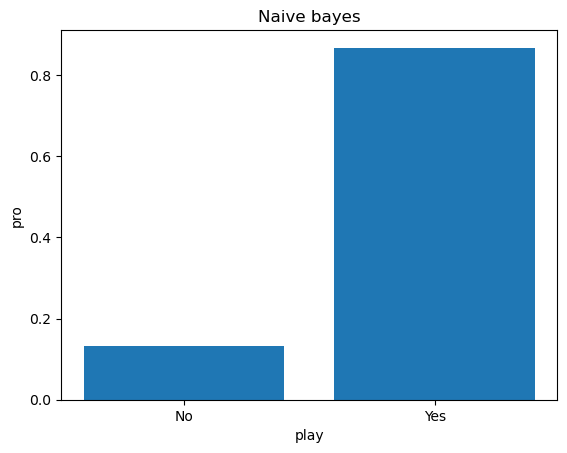

In [12]:
labels=["No","Yes"]
plt.figure()
plt.bar(labels,pro)
plt.xlabel("play")
plt.ylabel("pro")
plt.title("Naive bayes")
plt.show()